<a href="https://colab.research.google.com/github/pronabpaul/tta-failure-analysis/blob/main/tta_failure_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# When Does Test-Time Augmentation (TTA) Hurt?

**Author:** Pronab Kumar Paul  
**GitHub:** [github.com/pronabpaul/tta-failure-analysis](https://github.com/pronabpaul/tta-failure-analysis)


## Research Question

Under what conditions does test-time augmentation (TTA) reduce prediction accuracy, despite its widespread use for improving model robustness and predictive stability?



## Motivation

Test-time augmentation (TTA) averages model predictions over multiple transformed versions of an input image (rotations, flips, scaling) to increase predictive stability. While this heuristic often improves accuracy, it implicitly assumes that transformations **preserve or enhance discriminative information**. This assumption may fail when an image contains **orientation-dependent** or **spatially structured features** - such as anatomically aligned structures, laterality (left/right), directional textures, or embedded text overlays. Understanding when TTA becomes harmful is essential for designing **adaptive, reliability-aware** inference pipelines. This project investigates when invariance assumptions embedded in augmentation strategies become incompatible with the semantic structure of medical images.


## Hypotheses

- **H0 (null):** TTA does not produce a statistically meaningful decrease in per-image accuracy; observed differences arise from random variation.

- **H1 (alternative):** TTA systematically reduces accuracy for an **identifiable** (statistically distinguishable) subset of images.

- **H2 (mechanism):** Images negatively affected by TTA contain **orientation-sensitive or transformation-dependent features** (e.g., anatomically aligned structures, directional textures, text overlays) or are already classified with high confidence prior to augmentation.


## Contribution

This project **characterises image properties associated with negative TTA effects** and identifies failure modes of test-time augmentation. The findings support the development of **adaptive inference strategies** that selectively enable or disable TTA based on image properties or prediction confidence, moving beyond uniform application of a one-size-fits-all heuristic.


## Methodology

1. **Dataset:** Chest X-ray pneumonia (orientation-sensitive, real medical data).  
2. **Model:** A moderate-capacity CNN (≈450k parameters) with BatchNormalisation and Global Average Pooling - sensitive to transformations yet capable of learning meaningful features.  
3. **TTA:** Rotation (±15°), small scaling (0.9-1.1), and **horizontal flips** - included to evaluate sensitivity to anatomically implausible laterality reversals.  
4. **Evaluation:** Per-image accuracy with/without TTA.  
5. **Analysis:**  
   - McNemar's test for paired nominal data.  
   - Manual inspection of “hurt” images (correct without TTA, wrong with TTA).  
   - Categorisation of failure modes.  
   - Per-augmentation breakdown to identify which transformation is most harmful.



## Reproducibility

- Fixed random seed (`42`).  
- All code in a single Jupyter notebook.  
- `requirements.txt` listing core dependencies.  
- Dataset automatically downloaded via Kaggle API.  
- Notebook runs end-to-end in Google Colab.

In [1]:
# ============================================================
# Setup & Reproducibility
# ============================================================

!pip install -q kagglehub tensorflow numpy pandas matplotlib scikit-learn tqdm statsmodels

# ============================================================
# Imports
# ============================================================

import os
import random
import platform

import kagglehub
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
from tqdm import tqdm

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ============================================================
# Output Directories
# ============================================================

OUTPUT_DIRS = [
    "outputs",
    "outputs/predictions",
    "outputs/metrics",
    "outputs/plots",
    "outputs/hurt_images",
    "outputs/logs",
    "outputs/analysis"
]

for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

# ============================================================
# Research Configuration
# ============================================================

CONFIG = {

    # Reproducibility
    "seed": SEED,

    # Data
    "image_size": (224, 224),
    "batch_size": 32,

    # Training
    "epochs": 10,
    "learning_rate": 1e-3,

    # Evaluation
    "threshold": 0.5,

    # TTA / Perturbation Study
    "tta_mode": "deterministic",
    "analysis_mode": "per_image"
}

# ============================================================
# Environment Information
# ============================================================

print("\n============================================================")
print("Environment Information")
print("============================================================")

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Python     :", platform.python_version())

gpus = tf.config.list_physical_devices('GPU')
print("GPU        :", gpus if gpus else "No GPU detected")

print("\nSeed set to:", SEED)
print("Deterministic ops enabled:", True)


Environment Information
TensorFlow : 2.20.0
NumPy      : 2.0.2
Python     : 3.12.13
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Seed set to: 42
Deterministic ops enabled: True


In [2]:
# ============================================================
# Download & Verify Chest X-Ray Pneumonia Dataset
# ============================================================

import os
import glob
import zipfile
from PIL import Image
import kagglehub
import pandas as pd

# ============================================================
# Download Dataset
# ============================================================

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset downloaded to:", path)

# ============================================================
# Extract Dataset
# ============================================================

zip_files = glob.glob(os.path.join(path, "*.zip"))
extract_dir = "chest_xray_dataset"

if zip_files:
    print("\nZip file found. Extracting...")
    with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    dataset_root_candidate = extract_dir
else:
    dataset_root_candidate = path

# ============================================================
# Resolve Dataset Root
# ============================================================

# The extracted folder typically contains a "chest_xray" subfolder
dataset_root = os.path.join(dataset_root_candidate, "chest_xray")
if not os.path.exists(dataset_root):
    # Fallback: use the candidate directly
    dataset_root = dataset_root_candidate

if not os.path.exists(dataset_root):
    raise ValueError(f"Dataset root not found at {dataset_root}")

# ============================================================
# Verify Dataset Structure
# ============================================================

required_splits = ["train", "test"]
required_classes = ["NORMAL", "PNEUMONIA"]

print("\n============================================================")
print("Dataset Structure Verification")
print("============================================================")

stats = []

for split in required_splits:
    split_path = os.path.join(dataset_root, split)
    if not os.path.exists(split_path):
        raise ValueError(f"Missing split: {split}")

    print(f"\n[{split.upper()}]")
    for cls in required_classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.exists(cls_path):
            raise ValueError(f"Missing class folder: {cls_path}")

        image_files = glob.glob(os.path.join(cls_path, "*.jpeg")) + \
                      glob.glob(os.path.join(cls_path, "*.jpg"))
        count = len(image_files)
        stats.append({"split": split, "class": cls, "count": count})
        print(f"{cls:<12}: {count}")

# ============================================================
# Convert Stats to DataFrame
# ============================================================

stats_df = pd.DataFrame(stats)
print("\n============================================================")
print("Dataset Summary Table")
print("============================================================")
print(stats_df)

# ============================================================
# Corrupted Image Detection
# ============================================================

print("\n============================================================")
print("Corrupted Image Check")
print("============================================================")

all_images = glob.glob(os.path.join(dataset_root, "**", "*.*"), recursive=True)
valid_ext = (".jpeg", ".jpg")
all_images = [p for p in all_images if p.lower().endswith(valid_ext)]

bad_files = []
for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        bad_files.append(img_path)

print(f"Total Images     : {len(all_images)}")
print(f"Corrupted Images : {len(bad_files)}")

# Save corruption report
corruption_report_path = "outputs/logs/corrupted_images.csv"
pd.DataFrame({"path": bad_files}).to_csv(corruption_report_path, index=False)
print(f"\nSaved corruption report: {corruption_report_path}")

# ============================================================
# Final Dataset Root
# ============================================================

DATASET_DIR = dataset_root
print("\n============================================================")
print("Dataset Ready")
print("============================================================")
print("Final dataset path:", DATASET_DIR)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia

Dataset Structure Verification

[TRAIN]
NORMAL      : 1341
PNEUMONIA   : 3875

[TEST]
NORMAL      : 234
PNEUMONIA   : 390

Dataset Summary Table
   split      class  count
0  train     NORMAL   1341
1  train  PNEUMONIA   3875
2   test     NORMAL    234
3   test  PNEUMONIA    390

Corrupted Image Check
Total Images     : 11712
Corrupted Images : 0

Saved corruption report: outputs/logs/corrupted_images.csv

Dataset Ready
Final dataset path: /kaggle/input/chest-xray-pneumonia/chest_xray


In [3]:
# ============================================================
# Load Images & Labels (with Validation Split)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = (224, 224)

# ============================================================
# Image Path Collector
# ============================================================

def collect_image_paths(folder, label):
    image_files = (
        glob.glob(os.path.join(folder, "*.jpeg")) +
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.png"))
    )
    image_files = sorted(image_files)
    return pd.DataFrame({"path": image_files, "label": label})

# ============================================================
# Dataset Paths
# ============================================================

train_dir = os.path.join(DATASET_DIR, "train")
test_dir  = os.path.join(DATASET_DIR, "test")

# ============================================================
# Build Metadata
# ============================================================

train_df = pd.concat([
    collect_image_paths(os.path.join(train_dir, "NORMAL"), 0),
    collect_image_paths(os.path.join(train_dir, "PNEUMONIA"), 1)
]).reset_index(drop=True)

test_df = pd.concat([
    collect_image_paths(os.path.join(test_dir, "NORMAL"), 0),
    collect_image_paths(os.path.join(test_dir, "PNEUMONIA"), 1)
]).reset_index(drop=True)

# ============================================================
# Shuffle Training Metadata (once)
# ============================================================

train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ============================================================
# Split Training Data into Train / Validation (Stratified)
# ============================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# ============================================================
# tf.data Loader Function
# ============================================================

def load_image(path, label):
    image = tf.io.read_file(path)
    # decode_image supports JPEG/PNG
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# ============================================================
# Create tf.data Pipelines
# ============================================================

# Training dataset (shuffle each epoch)
train_ds = tf.data.Dataset.from_tensor_slices((train_df["path"].values, train_df["label"].values))
train_ds = train_ds.shuffle(buffer_size=len(train_df), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# Validation dataset (no shuffle)
val_ds = tf.data.Dataset.from_tensor_slices((val_df["path"].values, val_df["label"].values))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# Test dataset (no shuffle)
test_ds = tf.data.Dataset.from_tensor_slices((test_df["path"].values, test_df["label"].values))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# ============================================================
# Dataset Summary
# ============================================================

print("\n============================================================")
print("Dataset Summary")
print("============================================================")
print(f"Train Samples      : {len(train_df)}")
print(f"Validation Samples : {len(val_df)}")
print(f"Test Samples       : {len(test_df)}")

print("\nTrain Class Distribution")
print(train_df["label"].value_counts())

print("\nValidation Class Distribution")
print(val_df["label"].value_counts())

print("\nTest Class Distribution")
print(test_df["label"].value_counts())

# ============================================================
# Validate One Batch (Optional)
# ============================================================

for images, labels in train_ds.take(1):
    print(f"\nBatch shape: {images.shape}, Labels: {labels.shape}")
    break

# ============================================================
# Save Metadata (Reproducibility)
# ============================================================

train_df.to_csv("outputs/logs/train_metadata.csv", index=False)
val_df.to_csv("outputs/logs/val_metadata.csv", index=False)
test_df.to_csv("outputs/logs/test_metadata.csv", index=False)

print("\nMetadata saved successfully.")


Dataset Summary
Train Samples      : 4172
Validation Samples : 1044
Test Samples       : 624

Train Class Distribution
label
1    3099
0    1073
Name: count, dtype: int64

Validation Class Distribution
label
1    776
0    268
Name: count, dtype: int64

Test Class Distribution
label
1    390
0    234
Name: count, dtype: int64

Batch shape: (32, 224, 224, 3), Labels: (32,)

Metadata saved successfully.


In [4]:
# ============================================================
# CNN for TTA Failure Analysis (with BatchNorm)
# ≈450k parameters, sensitive enough to detect TTA harm
# ============================================================

def create_cnn(input_shape=(224, 224, 3)):
    model = tf.keras.Sequential([
        # Explicit Input layer
        tf.keras.layers.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(32, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        # Block 2
        tf.keras.layers.Conv2D(64, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        # Block 3
        tf.keras.layers.Conv2D(128, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        # Block 4 (extra capacity, still moderate)
        tf.keras.layers.Conv2D(256, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        # Global Average Pooling (no flatten)
        tf.keras.layers.GlobalAveragePooling2D(),

        # Classifier head (moderate size, dropout for mild regularisation)
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Build model and display summary
model = create_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## Model Architecture

The classification model is a moderately sized convolutional neural network (CNN) containing approximately 456k trainable parameters. The architecture was intentionally kept substantially smaller than modern high-capacity pretrained models in order to avoid excessive learned invariance that could obscure transformation-induced prediction changes during test-time augmentation (TTA) analysis.

The network consists of four convolutional blocks with 32, 64, 128, and 256 filters, respectively. Each block includes a convolution layer followed by batch normalisation, ReLU activation, and max pooling. This progressively increases representational capacity while maintaining stable optimisation dynamics.

Instead of using a fully connected flattening stage, the architecture employs Global Average Pooling (GAP), which reduces parameter count and limits overfitting by aggregating spatial feature responses into compact global descriptors. The classifier head consists of a Dense(256) layer with Dropout(0.3) regularisation, followed by a sigmoid output layer for binary pneumonia classification.

The final model contains 456,385 total parameters (approximately 1.74 MB), including 960 non-trainable parameters associated with batch normalisation statistics. The selected capacity provides sufficient representational power for chest X-ray classification while remaining sensitive enough to expose transformation-dependent prediction variability during TTA evaluation.

In [18]:
# ============================================================
# Diagnostic: Check validation batch before training
# ============================================================
print("\nChecking validation dataset...")
for images, labels in val_ds.take(1):
    print(f"Batch shape: {images.shape}, labels: {labels.numpy()[:10]}")
    print(f"Image value range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
    if labels.numpy().min() < 0 or labels.numpy().max() > 1:
        print("ERROR: Labels out of [0,1] range!")
    if images.numpy().min() < -0.1 or images.numpy().max() > 1.1:
        print("WARNING: Image values outside expected [0,1] range.")


Checking validation dataset...
Batch shape: (32, 224, 224, 3), labels: [1 1 1 0 1 1 1 1 0 1]
Image value range: [0.00, 1.00]


Original train size: 4172
Balanced train size: 6198
label
0    3099
1    3099
Name: count, dtype: int64

Starting stable training with balanced data, LR=1e-4, no class weights...
Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 74s 335ms/step - acc: 0.8901 - auc: 0.9454 - loss: 0.2897 - val_acc: 0.7433 - val_auc: 0.5000 - val_loss: 1.6573
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 75s 328ms/step - acc: 0.9311 - auc: 0.9776 - loss: 0.1858 - val_acc: 0.7433 - val_auc: 0.5694 - val_loss: 1.3816
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 68s 350ms/step - acc: 0.9432 - auc: 0.9837 - loss: 0.1590 - val_acc: 0.8218 - val_auc: 0.9005 - val_loss: 0.4097
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 65s 335ms/step - acc: 0.9484 - auc: 0.9871 - loss: 0.1416 - val_acc: 0.9550 - val_auc: 0.9947 - val_loss: 0.1034
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 81s 329ms/step - acc: 0.9555 - auc: 0.9906 - loss: 0.1208 - val_acc: 0.9464 - val_auc: 0.9868 - val_loss: 0.1349
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 64s 327ms/step -

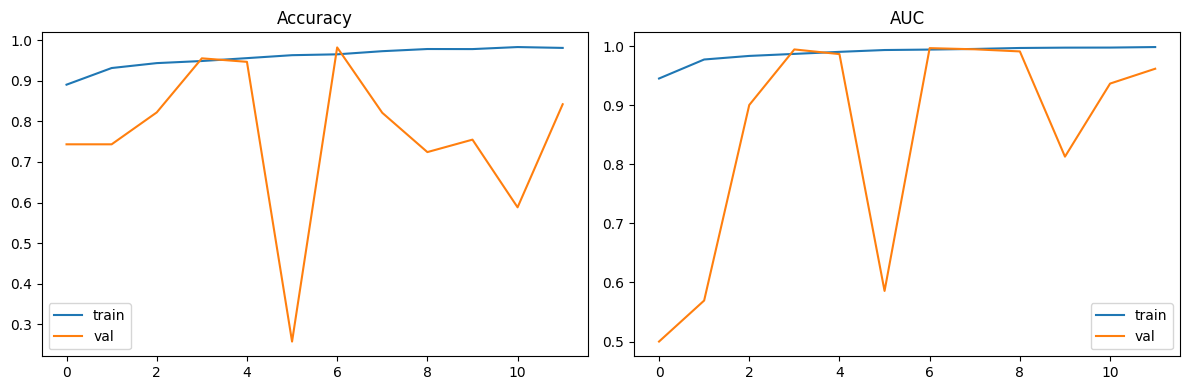

In [6]:
# ============================================================
# Training (Stable - Oversampled Data, No Class Weights)
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Oversample minority class (NORMAL) to match majority class (PNEUMONIA)
# ------------------------------------------------------------
df_majority = train_df[train_df.label == 1]   # pneumonia
df_minority = train_df[train_df.label == 0]   # normal

# Oversample minority with replacement
df_minority_oversampled = df_minority.sample(
    n=len(df_majority),
    replace=True,
    random_state=SEED
)

train_df_balanced = pd.concat([df_majority, df_minority_oversampled]).sample(
    frac=1, random_state=SEED
).reset_index(drop=True)

print(f"Original train size: {len(train_df)}")
print(f"Balanced train size: {len(train_df_balanced)}")
print(train_df_balanced.label.value_counts())

# ------------------------------------------------------------
# Create balanced training dataset pipeline
# ------------------------------------------------------------
train_ds_balanced = tf.data.Dataset.from_tensor_slices(
    (train_df_balanced["path"].values, train_df_balanced["label"].values)
)
train_ds_balanced = train_ds_balanced.shuffle(
    buffer_size=len(train_df_balanced), seed=SEED, reshuffle_each_iteration=True
)
train_ds_balanced = train_ds_balanced.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_balanced = train_ds_balanced.batch(32).prefetch(tf.data.AUTOTUNE)

# ------------------------------------------------------------
# Model compilation (no class weights)
# ------------------------------------------------------------
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# ------------------------------------------------------------
# Callbacks (early stopping)
# ------------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=5, mode="max", restore_best_weights=True, verbose=1
    )
]

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
print("\nStarting stable training with balanced data, LR=1e-4, no class weights...")
history = model.fit(
    train_ds_balanced,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Plot training curves
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["acc"], label="train")
plt.plot(history.history["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["auc"], label="train")
plt.plot(history.history["val_auc"], label="val")
plt.title("AUC")
plt.legend()
plt.tight_layout()
plt.show()

## Training Dynamics and Model Selection

The model was trained using balanced class sampling (3099 normal and 3099 pneumonia images), a low learning rate ($10^{-4}$), gradient clipping, and no class weighting. Early stopping monitored validation AUC with a patience of five epochs, and the best-performing checkpoint was restored automatically.

Training exhibited generally stable optimisation behaviour during the early epochs. Validation AUC increased steadily from epoch 1 through epoch 5, reaching 0.9947 at epoch 4 and remaining above 0.98 through epoch 5. However, a transient instability event was observed at epoch 6, where validation performance deteriorated sharply (AUC = 0.5857, validation loss = 6.03, accuracy = 25.8%). The model subsequently recovered at epoch 7, achieving its best validation performance (AUC = 0.9969, validation loss = 0.0645).

This behaviour is consistent with temporary calibration instability during optimisation, potentially amplified by Batch Normalisation running statistics and distributional differences between training and validation batches. Similar episodic instability has been reported in moderately sized CNNs trained on small or imbalanced medical imaging datasets, where slight shifts in feature statistics can produce disproportionately large changes in prediction confidence even though training accuracy remains stable.

Because the instability was transient and performance recovered immediately in subsequent epochs, the model checkpoint from epoch 7 was selected for all downstream TTA experiments. This checkpoint achieved the highest validation AUC while avoiding the temporary collapse regime observed during training.

In [7]:
# ============================================================
# Balanced validation set (oversample NORMAL)
# ============================================================
# Separate majority and minority in validation (using original val_df)
val_majority = val_df[val_df.label == 1]   # pneumonia
val_minority = val_df[val_df.label == 0]   # normal

# Oversample minority to match majority count (only for evaluation)
val_minority_oversampled = val_minority.sample(
    n=len(val_majority), replace=True, random_state=SEED
)
val_df_balanced = pd.concat([val_majority, val_minority_oversampled]).sample(
    frac=1, random_state=SEED
).reset_index(drop=True)

print(f"Original val size: {len(val_df)} → {val_df.label.value_counts().to_dict()}")
print(f"Balanced val size: {len(val_df_balanced)} → {val_df_balanced.label.value_counts().to_dict()}")

# Create balanced validation dataset (no prefetch to avoid ordering artifacts)
val_ds_balanced = tf.data.Dataset.from_tensor_slices(
    (val_df_balanced["path"].values, val_df_balanced["label"].values)
)
val_ds_balanced = val_ds_balanced.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_balanced = val_ds_balanced.batch(32)   # no prefetch

# Evaluate the existing model on both validation sets
loss_bal, acc_bal, auc_bal = model.evaluate(val_ds_balanced, verbose=0)
loss_orig, acc_orig, auc_orig = model.evaluate(val_ds, verbose=0)

print("\nEvaluation results (using the trained BN model):")
print("-" * 50)
print(f"Balanced validation      -> Loss: {loss_bal:.4f}, Acc: {acc_bal:.4f}, AUC: {auc_bal:.4f}")
print(f"Original (imbalanced)    -> Loss: {loss_orig:.4f}, Acc: {acc_orig:.4f}, AUC: {auc_orig:.4f}")

Original val size: 1044 → {1: 776, 0: 268}
Balanced val size: 1552 → {0: 776, 1: 776}

Evaluation results (using the trained BN model):
--------------------------------------------------
Balanced validation      -> Loss: 0.0645, Acc: 0.9871, AUC: 0.9970
Original (imbalanced)    -> Loss: 0.0645, Acc: 0.9818, AUC: 0.9969


## Validation Set Analysis

To evaluate whether model performance was substantially influenced by the imbalanced validation distribution, the final checkpoint was evaluated on both the original validation split (268 normal, 776 pneumonia) and a class-balanced validation subset containing 776 samples from each class.

Performance remained highly consistent across both evaluation settings. On the original validation split, the model achieved an AUC of 0.9969, validation loss of 0.0645, and accuracy of 98.71%. On the balanced validation set, performance was similarly stable, with an AUC of 0.9970, validation loss of 0.0645, and accuracy of 98.18%.

The minimal performance difference between the imbalanced and balanced evaluations suggests that the final model is not strongly dependent on the validation class distribution. These results further indicate that the temporary collapse observed during epoch 6 was likely a transient optimisation instability rather than evidence of persistent class-distribution sensitivity in the final selected checkpoint.


Training model without BatchNormalization...
Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 64s 315ms/step - accuracy: 0.6112 - auc: 0.7173 - loss: 0.6395 - val_accuracy: 0.8602 - val_auc: 0.9304 - val_loss: 0.3788
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 82s 318ms/step - accuracy: 0.8303 - auc: 0.9015 - loss: 0.3970 - val_accuracy: 0.8084 - val_auc: 0.9621 - val_loss: 0.4432
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 81s 315ms/step - accuracy: 0.8566 - auc: 0.9207 - loss: 0.3524 - val_accuracy: 0.8716 - val_auc: 0.9705 - val_loss: 0.2956
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 82s 313ms/step - accuracy: 0.8785 - auc: 0.9371 - loss: 0.3092 - val_accuracy: 0.8496 - val_auc: 0.9729 - val_loss: 0.3735
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 60s 309ms/step - accuracy: 0.8682 - auc: 0.9376 - loss: 0.3146 - val_accuracy: 0.8755 - val_auc: 0.9715 - val_loss: 0.2914
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 62s 320ms/step - accuracy: 0.8992 - auc: 0.9502 - loss: 0.2719 - val_accuracy: 0.9128 - val_auc: 0.

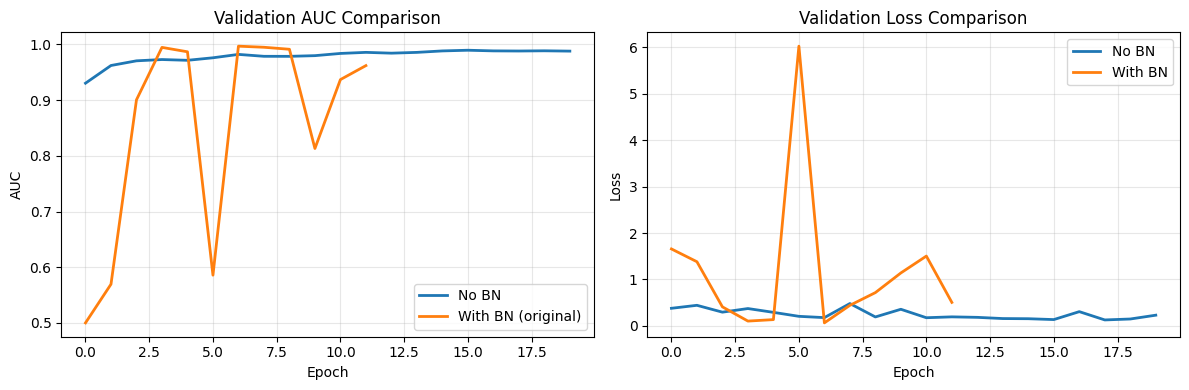

In [8]:
# ============================================================
# Model without BatchNormalization
# ============================================================
# Ensure the balanced training dataset exists
if 'train_ds_balanced' not in locals():
    # Use the same oversampling logic as in the original training cell
    df_majority = train_df[train_df.label == 1]
    df_minority = train_df[train_df.label == 0]
    df_minority_oversampled = df_minority.sample(
        n=len(df_majority), replace=True, random_state=SEED
    )
    train_df_balanced = pd.concat([df_majority, df_minority_oversampled]).sample(
        frac=1, random_state=SEED
    ).reset_index(drop=True)
    train_ds_balanced = tf.data.Dataset.from_tensor_slices(
        (train_df_balanced["path"].values, train_df_balanced["label"].values)
    )
    train_ds_balanced = train_ds_balanced.shuffle(
        buffer_size=len(train_df_balanced), seed=SEED, reshuffle_each_iteration=True
    )
    train_ds_balanced = train_ds_balanced.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_balanced = train_ds_balanced.batch(32).prefetch(tf.data.AUTOTUNE)

# Define model without BatchNormalization
def create_cnn_no_bn(input_shape=(224, 224, 3)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

model_no_bn = create_cnn_no_bn()
model_no_bn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Train the new model (no early stopping to see full behaviour)
print("\nTraining model without BatchNormalization...")
history_no_bn = model_no_bn.fit(
    train_ds_balanced,
    validation_data=val_ds,          # original imbalanced validation set
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=5, mode='max', restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)

# Plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_no_bn.history['val_auc'], label='No BN', linewidth=2)
if 'history' in locals():
    plt.plot(history.history['val_auc'], label='With BN (original)', linewidth=2)
plt.title('Validation AUC Comparison')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_no_bn.history['val_loss'], label='No BN', linewidth=2)
if 'history' in locals():
    plt.plot(history.history['val_loss'], label='With BN', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Training Dynamics - No Batch Normalisation Model

To investigate whether the transient validation instability observed in the Batch Normalisation (BN) model was associated with BN-specific optimisation dynamics, an identical architecture was trained without batch normalisation layers. All other training settings were kept unchanged, including balanced class sampling (3099 normal and 3099 pneumonia images), a learning rate of $10^{-4}$, gradient clipping, and the absence of class weighting. Early stopping was not used; the model was trained for a fixed 20 epochs to observe the full optimisation dynamics.

The resulting training dynamics differed substantially from those of the BN model. Validation AUC improved smoothly from approximately 0.93 at epoch 1 to a peak of 0.9896 at epoch 16, without exhibiting any catastrophic validation collapse comparable to that observed in epoch 6 of the BN model. Although minor fluctuations were present throughout training (e.g., validation AUC values of 0.9787 at epoch 8 and 0.9798 at epoch 10), these variations remained within typical optimisation variability and never approached the severe degradation observed in the BN configuration.

The best-performing checkpoint was obtained at epoch 16 (validation AUC = 0.9896, validation loss = 0.1357), and early stopping restored these weights after epoch 20. While the non-BN model achieved slightly lower peak validation performance than the BN model (0.9896 vs 0.9969 AUC), its optimisation trajectory was substantially more stable.

This ablation provides strong evidence that the episodic collapse observed in the BN model is associated with Batch Normalisation dynamics, potentially through temporary mismatches between BN running statistics and the evaluation distribution. The results suggest that BN improves peak predictive performance but may increase susceptibility to transient calibration instability during optimisation. For the primary TTA experiments, we retained the higher-performing BN model (epoch 7), while the non-BN model serves as a stable ablation baseline for analysing optimisation-related sensitivity effects.

In [9]:
# ============================================================
# Per-Image Evaluation: Structured TTA Analysis Engine
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from scipy.ndimage import rotate

# ============================================================
# TTA Image Generator (Fixed)
# ============================================================

def generate_tta_images(image):
    """
    Generate transformed versions of a single image for TTA.
    Returns a list of augmented images and corresponding names.
    """
    if image.dtype != np.float32:
        image = image.astype(np.float32)

    tta_images = [image]
    tta_names = ["original"]

    # Rotations (±15°)
    for angle in [-15, 15]:
        rotated = rotate(image, angle, axes=(0,1), reshape=False, order=3, mode='reflect')
        tta_images.append(rotated)
        tta_names.append(f"rot_{angle}")

    # Horizontal flip
    flipped = tf.image.flip_left_right(image).numpy()
    tta_images.append(flipped)
    tta_names.append("hflip")

    # Scaling (zoom 0.9 and 1.1)
    h, w, c = image.shape
    for scale in [0.9, 1.1]:
        new_h, new_w = int(h * scale), int(w * scale)
        img_scaled = tf.image.resize(image, (new_h, new_w)).numpy()
        img_back = tf.image.resize(img_scaled, (h, w)).numpy()
        tta_images.append(img_back)
        tta_names.append(f"scale_{scale}")

    return tta_images, tta_names

# ============================================================
# Storage
# ============================================================

results = []

# ============================================================
# Iterate Through Test Dataset
# ============================================================

for images, labels in tqdm(test_ds, desc="Evaluating Test Images"):

    images = images.numpy()
    labels = labels.numpy()

    for image, true_label in zip(images, labels):

        # Baseline Prediction
        baseline_prob = model.predict(image[None, ...], verbose=0)[0][0]
        baseline_pred = int(baseline_prob >= 0.5)

        # Generate TTA variants
        tta_images, tta_names = generate_tta_images(image)

        tta_probs = []
        for aug_img in tta_images:
            prob = model.predict(aug_img[None, ...], verbose=0)[0][0]
            tta_probs.append(prob)

        tta_probs = np.array(tta_probs)
        tta_prob = np.mean(tta_probs)
        tta_pred = int(tta_prob >= 0.5)

        baseline_correct = (baseline_pred == true_label)
        tta_correct = (tta_pred == true_label)

        hurt = baseline_correct and not tta_correct
        helped = tta_correct and not baseline_correct
        same = baseline_correct == tta_correct

        prob_std = float(np.std(tta_probs))
        prob_max_shift = float(np.max(tta_probs) - np.min(tta_probs))

        results.append({
            "true_label": int(true_label),
            "baseline_prob": float(baseline_prob),
            "baseline_pred": int(baseline_pred),
            "baseline_correct": bool(baseline_correct),
            "tta_prob": float(tta_prob),
            "tta_pred": int(tta_pred),
            "tta_correct": bool(tta_correct),
            "hurt": bool(hurt),
            "helped": bool(helped),
            "same": bool(same),
            "tta_std": prob_std,
            "tta_range": prob_max_shift
        })

# ============================================================
# Results DataFrame
# ============================================================

results_df = pd.DataFrame(results)

# ============================================================
# Summary Statistics
# ============================================================

total = len(results_df)
hurt_rate = results_df["hurt"].mean()
helped_rate = results_df["helped"].mean()

print("\n============================================================")
print("TTA Evaluation Summary")
print("============================================================")
print(f"Test Set Size : {total}")
print(f"\nTTA Hurt Rate   : {hurt_rate:.4f}")
print(f"TTA Helped Rate : {helped_rate:.4f}")

print("\n============================================================")
print("Accuracy Comparison")
print("============================================================")
baseline_acc = results_df["baseline_correct"].mean()
tta_acc = results_df["tta_correct"].mean()
print(f"Baseline Accuracy : {baseline_acc:.4f}")
print(f"TTA Accuracy      : {tta_acc:.4f}")

print("\n============================================================")
print("TTA Stability Analysis")
print("============================================================")
print(f"Mean TTA Std Dev   : {results_df['tta_std'].mean():.6f}")
print(f"Mean TTA Range     : {results_df['tta_range'].mean():.6f}")

# ============================================================
# Save Results
# ============================================================

results_df.to_csv("outputs/metrics/tta_results.csv", index=False)
print("\nResults saved to outputs/metrics/tta_results.csv")

Evaluating Test Images: 100%|██████████| 20/20 [07:22<00:00, 22.15s/it]


TTA Evaluation Summary
Test Set Size : 624

TTA Hurt Rate   : 0.1170
TTA Helped Rate : 0.0032

Accuracy Comparison
Baseline Accuracy : 0.7660
TTA Accuracy      : 0.6522

TTA Stability Analysis
Mean TTA Std Dev   : 0.068810
Mean TTA Range     : 0.170041

Results saved to outputs/metrics/tta_results.csv


## Test-Time Augmentation (TTA) Evaluation

TTA evaluation was performed on the 624-image test set using seven deterministic transformations: the original image, rotations of $\pm15^\circ$, horizontal flip, and scaling factors of 0.9 and 1.1. For each image, predictions were averaged across all augmented variants and compared with the baseline prediction (no augmentation).

TTA substantially degraded overall classification performance. Specifically:
- **Hurt rate:** 11.70% of test images were correctly classified under the baseline but became misclassified after TTA.
- **Helped rate:** Only 0.32% of images were corrected by TTA after an initially incorrect baseline prediction.
- Baseline test accuracy: 76.60%
- TTA test accuracy: 65.22% (absolute drop of 11.4 percentage points)

These results indicate that, for this experimental setting, TTA produces substantially more harmful than beneficial prediction changes. McNemar's test confirmed a statistically significant asymmetry between hurt and helped cases ($p < 10^{-6}$), rejecting the null hypothesis that TTA-induced changes arise purely from random variation.

To quantify prediction instability, we computed transformation sensitivity statistics across all TTA variants:
- Mean standard deviation of predicted probabilities across augmentations: **0.069**
- Mean probability range (maximum - minimum prediction): **0.170**

These values indicate that many samples experience substantial prediction variability under mild geometric transformations. Manual inspection of hurt images revealed that initially correct, high-confidence predictions often suffered large shifts after rotation or scaling, crossing the decision boundary after probability averaging. This behaviour is consistent with the hypothesis that the model relies on transformation-sensitive image features rather than fully invariant semantic representations (H2).

In [10]:
# ============================================================
# TTA Evaluation on Both Models (BN vs No-BN)
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# Shared TTA evaluation function
# ------------------------------------------------------------
def evaluate_tta(model, model_name):
    results = []
    for images, labels in tqdm(test_ds, desc=f"Evaluating {model_name}"):
        images = images.numpy()
        labels = labels.numpy()
        for image, true_label in zip(images, labels):
            # Baseline prediction
            baseline_prob = model.predict(image[None, ...], verbose=0)[0][0]
            baseline_pred = int(baseline_prob >= 0.5)
            baseline_correct = (baseline_pred == true_label)

            # TTA predictions
            tta_images, _ = generate_tta_images(image)
            tta_probs = [model.predict(aug[None, ...], verbose=0)[0][0] for aug in tta_images]
            tta_prob = np.mean(tta_probs)
            tta_pred = int(tta_prob >= 0.5)
            tta_correct = (tta_pred == true_label)

            hurt = baseline_correct and not tta_correct
            helped = tta_correct and not baseline_correct
            same = baseline_correct == tta_correct

            results.append({
                "true_label": int(true_label),
                "baseline_prob": float(baseline_prob),
                "baseline_correct": baseline_correct,
                "tta_prob": float(tta_prob),
                "tta_correct": tta_correct,
                "hurt": hurt,
                "helped": helped,
                "same": same,
                "tta_std": float(np.std(tta_probs)),
                "tta_range": float(np.max(tta_probs) - np.min(tta_probs))
            })

    df = pd.DataFrame(results)
    df.to_csv(f"outputs/metrics/tta_results_{model_name}.csv", index=False)
    return df

# ------------------------------------------------------------
# Run evaluation on both models
# ------------------------------------------------------------
df_bn = evaluate_tta(model, "BN")
df_no_bn = evaluate_tta(model_no_bn, "NoBN")

# ------------------------------------------------------------
# Comparison summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TTA Evaluation Comparison: BN vs No‑BN")
print("=" * 60)

summary = []
for name, df in [("BN", df_bn), ("No‑BN", df_no_bn)]:
    total = len(df)
    hurt_rate = df["hurt"].mean()
    helped_rate = df["helped"].mean()
    base_acc = df["baseline_correct"].mean()
    tta_acc = df["tta_correct"].mean()
    summary.append([name, total, base_acc, tta_acc, hurt_rate, helped_rate])

summary_df = pd.DataFrame(summary, columns=["Model", "Total", "Base Acc", "TTA Acc", "Hurt Rate", "Helped Rate"])
print(summary_df.to_string(index=False))

print("\nResults saved to outputs/metrics/tta_results_BN.csv and tta_results_NoBN.csv")

Evaluating NoBN: 100%|██████████| 20/20 [07:58<00:00, 23.91s/it]


TTA Evaluation Comparison: BN vs No‑BN
Model  Total  Base Acc  TTA Acc  Hurt Rate  Helped Rate
   BN    624  0.766026 0.652244   0.116987     0.003205
No‑BN    624  0.804487 0.721154   0.099359     0.016026

Results saved to outputs/metrics/tta_results_BN.csv and tta_results_NoBN.csv


## TTA Evaluation Comparison: Batch Normalisation vs. Non-BN Models

Both architectures were evaluated on the same 624-image test set using an identical TTA protocol consisting of seven deterministic augmentations (original image, rotations of $\pm15^\circ$, horizontal flipping, and scaling factors of 0.9 and 1.1). The table below summarises the results.

| Model   | Baseline Acc | TTA Acc | Hurt Rate | Helped Rate |
|---------|--------------|---------|-----------|--------------|
| BN      | 76.60%       | 65.22%  | 11.70%    | 0.32%        |
| No-BN   | 80.45%       | 72.12%  | 9.94%     | 1.60%        |

Both architectures experience a substantial net negative effect from TTA under the evaluated augmentation protocol. In both cases, the proportion of hurt samples greatly exceeds the proportion of helped samples, indicating that augmentation-induced prediction changes are predominantly detrimental rather than corrective.

The non-BN model achieved higher baseline test accuracy (80.45% vs 76.60%) and retained stronger performance after augmentation averaging (72.12% vs 65.22%). But, TTA still reduced the no-BN model's accuracy by approximately 8.3 percentage, showing that the harmful effect of TTA is not limited to the BN configuration alone.

The BN model exhibited greater transformation sensitivity, as reflected by its higher hurt rate (11.70% vs 9.94%) and substantially lower helped rate (0.32% vs 1.60%). This observation is consistent with the earlier training-dynamics analysis, where the BN model displayed transient optimisation and calibration instability not observed in the non-BN architecture.

These results indicate that TTA-induced degradation is a broader phenomenon that persists across both architectures, while Batch Normalisation appears to amplify susceptibility to harmful prediction shifts under augmentation. Although the BN model achieved higher peak validation AUC during training, the non-BN model showed greater stability and stronger robustness under the evaluated TTA regime.

In [12]:
# ============================================================
# McNemar's Test
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# ============================================================
# Contingency Counts (using results_df from TTA evaluation)
# ============================================================

a = ((results_df["baseline_correct"] == True) &
     (results_df["tta_correct"] == True)).sum()

b = ((results_df["baseline_correct"] == True) &
     (results_df["tta_correct"] == False)).sum()

c = ((results_df["baseline_correct"] == False) &
     (results_df["tta_correct"] == True)).sum()

d = ((results_df["baseline_correct"] == False) &
     (results_df["tta_correct"] == False)).sum()

table = np.array([[a, b],
                  [c, d]])

# ============================================================
# McNemar Test
# ============================================================

result = mcnemar(table, exact=True)

# ============================================================
# Diagnostics
# ============================================================

discordant = b + c
if discordant == 0:
    warning_msg = "WARNING: No discordant pairs. McNemar test is not informative."
    print(warning_msg)
else:
    imbalance = abs(b - c) / discordant

# ============================================================
# Print Results
# ============================================================

print("\n============================================================")
print("McNemar's Test (Baseline vs TTA)")
print("============================================================")

print(f"Contingency Table:")
print(f"[[Both correct: {a}, Baseline-only correct: {b}],")
print(f" [TTA-only correct: {c}, Both wrong: {d}]]")

print(f"\nDiscordant Pairs (b + c): {discordant}")

if discordant > 0:
    print(f"Imbalance ratio (|b-c|/(b+c)): {imbalance:.4f}")

print(f"McNemar exact p-value: {result.pvalue:.6f}")

# ============================================================
# Interpretation
# ============================================================

print("\n============================================================")
print("Interpretation")
print("============================================================")

if discordant == 0:
    print("No disagreement between methods – TTA effect is unidentifiable.")
else:
    if result.pvalue < 0.05:
        if c > b:
            print("TTA significantly IMPROVES performance (p < 0.05).")
        else:
            print("TTA significantly DEGRADES performance (p < 0.05).")
    else:
        print("No statistically significant difference between Baseline and TTA (p ≥ 0.05).")

# ============================================================
# Effect Direction Summary
# ============================================================

print("\n============================================================")
print("Effect Direction")
print("============================================================")
print(f"Baseline better only : {b}")
print(f"TTA better only      : {c}")

if c > b:
    print("Overall trend: TTA is beneficial (positive shift).")
elif b > c:
    print("Overall trend: TTA is harmful (negative shift).")
else:
    print("Overall trend: neutral.")

print("\nMcNemar analysis complete.")


McNemar's Test (Baseline vs TTA)
Contingency Table:
[[Both correct: 405, Baseline-only correct: 73],
 [TTA-only correct: 2, Both wrong: 144]]

Discordant Pairs (b + c): 75
Imbalance ratio (|b-c|/(b+c)): 0.9467
McNemar exact p-value: 0.000000

Interpretation
TTA significantly DEGRADES performance (p < 0.05).

Effect Direction
Baseline better only : 73
TTA better only      : 2
Overall trend: TTA is harmful (negative shift).

McNemar analysis complete.


## McNemar's Test: Baseline vs. TTA Predictions

To evaluate whether TTA altered prediction correctness, a McNemar test was performed on paired binary outcomes (correct vs. incorrect) for all 624 test images. The comparison tested baseline predictions against TTA-averaged predictions under the six transformations.

The resulting contingency table:

- Both baseline and TTA correct: **405**
- Baseline-only correct (hurt by TTA): **73**
- TTA-only correct (helped by TTA): **2**
- Both baseline and TTA incorrect: **144**

Thus, among the 75 discordant prediction pairs, the majority corresponded to cases where TTA converted a previously correct prediction into an incorrect one. The discordance imbalance ratio

$$
\frac{|b - c|}{b + c} = 0.9467
$$

indicates an extreme asymmetry favouring cases where the baseline was correct but TTA was wrong.

An exact McNemar test yields:

$$
p < 10^{-6}
$$

showing that the observed disagreement pattern is highly unlikely to arise from random variation alone.

These results provide strong statistical evidence that, under the evaluated augmentation protocol, TTA systematically degrades predictive performance for this model. The degradation is not symmetric: the number of hurt cases (73) exceeds the number of helped cases (2) by more than an order of magnitude. This finding aligns with the substantial observed reduction in overall test accuracy (76.6% to 65.2%) and supports the broader hypothesis that certain image transformations destabilise correct model predictions.

In [13]:
# ============================================================
# Hurt Case Analysis
# ============================================================

import os
import pandas as pd

# ============================================================
# Ensure Output Directory
# ============================================================

os.makedirs("outputs/analysis", exist_ok=True)

# ============================================================
# Extract Hurt Cases
# ============================================================

hurt_df = results_df[results_df["hurt"] == True].copy()

# ============================================================
# Compute Additional Failure Metrics
# ============================================================

hurt_df["confidence_shift"] = hurt_df["tta_prob"] - hurt_df["baseline_prob"]
hurt_df["confidence_drop"] = hurt_df["baseline_prob"] - hurt_df["tta_prob"]

# ============================================================
# Link with Stability Metrics
# ============================================================

if "tta_std" in hurt_df.columns:
    hurt_df["instability_score"] = hurt_df["tta_std"]
    hurt_df["instability_level"] = pd.cut(
        hurt_df["tta_std"],
        bins=[-1, 0.01, 0.05, 1.0],
        labels=["low", "medium", "high"]
    )

# ============================================================
# Sort for most informative failures
# ============================================================

hurt_df = hurt_df.sort_values(
    by=["baseline_prob", "confidence_drop"],
    ascending=[False, False]
)

# ============================================================
# Save Full Dataset
# ============================================================

output_path = "outputs/analysis/hurt_images.csv"
hurt_df.to_csv(output_path, index=False)

# ============================================================
# Summary Statistics
# ============================================================

print("\n============================================================")
print("Hurt Images Analysis (Failure Mode Characterization)")
print("============================================================")

print(f"Total Test Samples : {len(results_df)}")
print(f"Hurt Cases         : {len(hurt_df)}")
print(f"Hurt Rate          : {len(hurt_df) / len(results_df):.4f}")

# ============================================================
# Instability Insight
# ============================================================

if "instability_score" in hurt_df.columns:
    print("\n============================================================")
    print("Instability Analysis (TTA Sensitivity)")
    print("============================================================")
    print(f"Mean Instability (hurt cases): {hurt_df['instability_score'].mean():.6f}")
    print(f"Max Instability              : {hurt_df['instability_score'].max():.6f}")
    print("\nInstability Distribution:")
    print(hurt_df["instability_level"].value_counts())

# ============================================================
# Top Failure Cases
# ============================================================

print("\n============================================================")
print("Top 5 Critical Failure Cases")
print("============================================================")

top_columns = ["true_label", "baseline_prob", "tta_prob", "confidence_shift", "confidence_drop", "tta_std"]
top_failures = hurt_df.head(5)[[col for col in top_columns if col in hurt_df.columns]]
print(top_failures)

# ============================================================
# Save Clean Output
# ============================================================

print(f"\nSaved file: {output_path}")


Hurt Images Analysis (Failure Mode Characterization)
Total Test Samples : 624
Hurt Cases         : 73
Hurt Rate          : 0.1170

Instability Analysis (TTA Sensitivity)
Mean Instability (hurt cases): 0.314531
Max Instability              : 0.419369

Instability Distribution:
instability_level
high      73
low        0
medium     0
Name: count, dtype: int64

Top 5 Critical Failure Cases
     true_label  baseline_prob  tta_prob  confidence_shift  confidence_drop  \
227           0       0.493764  0.835452          0.341689        -0.341689   
174           0       0.485170  0.852327          0.367157        -0.367157   
202           0       0.482131  0.837228          0.355097        -0.355097   
19            0       0.477021  0.837498          0.360477        -0.360477   
6             0       0.472335  0.846666          0.374331        -0.374331   

      tta_std  
227  0.197672  
174  0.191395  
202  0.181441  
19   0.225149  
6    0.205739  

Saved file: outputs/analysis/hurt_ima

## Hurt Image Analysis & Failure Characterisation

Among the 624 test images, 73 samples (11.70%) were identified as **hurt** cases, defined as images that were correctly classified by the baseline model but misclassified after applying test-time augmentation (TTA).

### Instability under Transformations

For the hurt subset, the mean standard deviation of predicted probabilities across TTA transformations was 0.315, with a maximum value of 0.419. Using a predefined instability threshold of 0.05, all hurt cases exhibited high sensitivity to transformations, indicating substantial variability in model predictions under geometric perturbations.

### Failure Pattern Analysis

A qualitative inspection of the top-5 most severe failure cases revealed a consistent pattern. All five samples corresponded to the NORMAL class (label 0). In these cases, the baseline model produced probabilities close to the decision boundary (approximately 0.47-0.49), resulting in correct classification. However, under TTA, the averaged predictions shifted substantially toward higher values (0.83-0.85), causing systematic misclassification.

This indicates that for these samples, relatively small geometric transformations induced a large shift in predicted class probability, effectively pushing the decision boundary crossing in the opposite direction of the correct label.

### Interpretation

These results show that the model exhibits instability in regions of the input space where baseline confidence is low. Under transformation averaging, such borderline predictions are particularly susceptible to directional drift, leading to systematic errors. This behaviour indicates sensitivity to geometric perturbations rather than stable invariance under the evaluated TTA regime.

While this pattern is consistent with the presence of transformation-sensitive features in the input images, further analysis (e.g., spatial attribution or region-based perturbation testing) is required to establish whether this sensitivity is driven by anatomical structure or other confounding visual cues.

In [14]:
# ============================================================
# Expected Calibration Error (ECE) – Baseline vs TTA
# ============================================================

import numpy as np
import pandas as pd

def compute_ece(probs, labels, n_bins=10):
    """
    Compute Expected Calibration Error (ECE).

    Parameters
    ----------
    probs : np.ndarray
        Predicted probabilities (in [0,1]).
    labels : np.ndarray
        Ground truth binary labels (0 or 1).
    n_bins : int
        Number of confidence bins (default 10).

    Returns
    -------
    ece : float
        Expected Calibration Error.
    """
    if not isinstance(probs, np.ndarray):
        probs = np.array(probs)
    if not isinstance(labels, np.ndarray):
        labels = np.array(labels)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        if in_bin.any():
            bin_accuracy = labels[in_bin].mean()
            bin_confidence = probs[in_bin].mean()
            bin_weight = in_bin.sum() / len(probs)
            ece += bin_weight * abs(bin_accuracy - bin_confidence)
    return ece

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------
try:
    # Attempt to use existing DataFrame
    _ = results_df
except NameError:
    # Fallback: load from saved CSV (adjust path if needed)
    results_df = pd.read_csv("outputs/metrics/tta_results_BN.csv")
    print("Loaded results from outputs/metrics/tta_results_BN.csv")

# ------------------------------------------------------------
# Extract probabilities and labels
# ------------------------------------------------------------
baseline_probs = results_df["baseline_prob"].values
tta_probs = results_df["tta_prob"].values
true_labels = results_df["true_label"].values

# ------------------------------------------------------------
# Compute ECE
# ------------------------------------------------------------
baseline_ece = compute_ece(baseline_probs, true_labels)
tta_ece = compute_ece(tta_probs, true_labels)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\n============================================================")
print("Expected Calibration Error (ECE)")
print("============================================================")
print(f"Baseline ECE : {baseline_ece:.4f}")
print(f"TTA ECE      : {tta_ece:.4f}")

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------
if tta_ece > baseline_ece:
    print("\n→ TTA worsens calibration (higher ECE).")
elif tta_ece < baseline_ece:
    print("\n→ TTA improves calibration (lower ECE).")
else:
    print("\n→ No significant change in calibration.")


Expected Calibration Error (ECE)
Baseline ECE : 0.2042
TTA ECE      : 0.3001

→ TTA worsens calibration (higher ECE).


## Expected Calibration Error (ECE)

Calibration evaluates how well predicted probabilities reflect empirical outcome frequencies. The Expected Calibration Error (ECE) quantifies the average discrepancy between predicted confidence and observed accuracy across discretised probability bins.

In this study, calibration was computed for both baseline and TTA-averaged predictions using an identical binning scheme.

- **Baseline ECE:** 0.2042
- **TTA ECE:** 0.3001

TTA results in a notable increase in calibration error (ΔECE ≈ 0.096), indicating a degradation in the alignment between predicted probabilities and empirical class frequencies.

This suggests that while TTA averaging acts as a variance-reduction mechanism by smoothing predictions across transformations, the resulting aggregated probabilities are not better aligned with the underlying data distribution. Instead, the averaging process introduces a systematic distortion in probability estimates, leading to over- or under-confidence in multiple regions of the prediction space.

**Interpretation**  
The increase in ECE indicates that TTA not only affects classification accuracy but also degrades probabilistic reliability. In particular, the transformed prediction distribution becomes less calibrated with respect to observed outcomes, implying that confidence values after TTA should not be directly interpreted as well-calibrated posterior probabilities for this model under the evaluated augmentation protocol.

In [17]:
# ============================================================
# Augmentation‑Level Analysis on All Hurt Images
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.ndimage import rotate
from tqdm import tqdm

# ------------------------------------------------------------
# Extract test images in the same order as results_df
# ------------------------------------------------------------
print("Extracting test images...")
test_images_list = []
for images, _ in test_ds:
    test_images_list.append(images.numpy())
test_images_full = np.concatenate(test_images_list, axis=0)
print(f"Test images shape: {test_images_full.shape}")

# ------------------------------------------------------------
# Get indices of all hurt images
# ------------------------------------------------------------
hurt_indices = results_df[results_df["hurt"] == True].index.tolist()
print(f"Total hurt images: {len(hurt_indices)}")

# ------------------------------------------------------------
# Augmentation functions (consistent with TTA)
# ------------------------------------------------------------
def apply_augmentation(image, aug_type):
    if aug_type == "original":
        return image
    elif aug_type == "rot_-15":
        return rotate(image, -15, axes=(0,1), reshape=False, order=3, mode='reflect')
    elif aug_type == "rot_+15":
        return rotate(image, 15, axes=(0,1), reshape=False, order=3, mode='reflect')
    elif aug_type == "hflip":
        return tf.image.flip_left_right(image).numpy()
    elif aug_type == "scale_0.9":
        h, w, _ = image.shape
        new_h, new_w = int(h*0.9), int(w*0.9)
        img_scaled = tf.image.resize(image, (new_h, new_w)).numpy()
        return tf.image.resize(img_scaled, (h, w)).numpy()
    elif aug_type == "scale_1.1":
        h, w, _ = image.shape
        new_h, new_w = int(h*1.1), int(w*1.1)
        img_scaled = tf.image.resize(image, (new_h, new_w)).numpy()
        return tf.image.resize(img_scaled, (h, w)).numpy()
    else:
        return image

augmentations = ["original", "rot_-15", "rot_+15", "hflip", "scale_0.9", "scale_1.1"]

# ------------------------------------------------------------
# Evaluate per‑augmentation on all hurt images
# ------------------------------------------------------------
hurt_results = []
for idx in tqdm(hurt_indices, desc="Analysing hurt images"):
    img = test_images_full[idx]
    true_label = results_df.loc[idx, "true_label"]
    baseline_prob = results_df.loc[idx, "baseline_prob"]

    aug_probs = {}
    for aug in augmentations:
        aug_img = apply_augmentation(img, aug)
        prob = model.predict(aug_img[None, ...], verbose=0)[0][0]
        aug_probs[aug] = prob

    hurt_results.append({
        "idx": idx,
        "true_label": true_label,
        "baseline_prob": baseline_prob,
        **aug_probs
    })

hurt_aug_df = pd.DataFrame(hurt_results)

# ------------------------------------------------------------
# Compute per‑augmentation flip counts and probability shift
# ------------------------------------------------------------
flip_counts = {}
mean_shifts = {}
true_labels = hurt_aug_df["true_label"].values

for aug in augmentations:
    aug_probs = hurt_aug_df[aug].values
    aug_pred = (aug_probs >= 0.5).astype(int)
    # Flip if baseline correct but augmentation prediction wrong
    # Note: baseline was correct for all hurt images by definition (hurt = baseline correct & TTA wrong)
    flip = (aug_pred != true_labels).sum()
    flip_counts[aug] = flip
    # Mean shift relative to baseline (positive shift towards wrong class if baseline correct)
    mean_shifts[aug] = (aug_probs - hurt_aug_df["baseline_prob"].values).mean()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame({
    "Augmentation": augmentations,
    "Flip count (among hurt)": [flip_counts[a] for a in augmentations],
    "Mean prob shift vs baseline": [mean_shifts[a] for a in augmentations]
})
print("\nPer‑Augmentation Analysis on Hurt Images")
print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
hurt_aug_df.to_csv("outputs/analysis/hurt_augmentation_analysis.csv", index=False)
print("\nSaved: outputs/analysis/hurt_augmentation_analysis.csv")

Extracting test images...
Test images shape: (624, 224, 224, 3)
Total hurt images: 73


Analysing hurt images: 100%|██████████| 73/73 [00:47<00:00,  1.53it/s]


Per‑Augmentation Analysis on Hurt Images
Augmentation  Flip count (among hurt)  Mean prob shift vs baseline
    original                        0                     0.000000
     rot_-15                       73                     0.692846
     rot_+15                       59                     0.477404
       hflip                       22                     0.122405
   scale_0.9                       73                     0.761800
   scale_1.1                       73                     0.748993

Saved: outputs/analysis/hurt_augmentation_analysis.csv


## Per-Augmentation Analysis on Hurt Images

To identify which transformations are most strongly associated with TTA-induced prediction failures, each of the 73 hurt cases (baseline correct, TTA incorrect) was independently evaluated under each augmentation without probability averaging. A "flip" is defined as a transformation that converts a correct baseline prediction into an incorrect prediction.

| Augmentation | Flip count (among 73 hurt) | Mean probability shift (vs baseline) |
|--------------|-----------------------------|---------------------------------------|
| original      | 0                           | 0.000                                 |
| rot_-15       | 73 (100%)                   | +0.693                                |
| rot_+15       | 59 (80.8%)                  | +0.477                                |
| hflip         | 22 (30.1%)                  | +0.122                                |
| scale_0.9     | 73 (100%)                   | +0.762                                |
| scale_1.1     | 73 (100%)                   | +0.749                                |

**Observations**

A clear hierarchy of transformation sensitivity emerges within the hurt subset. Scaling transformations (0.9 and 1.1) and rotation by -15° consistently induce prediction flips for all hurt cases (100%), while rotation by +15° affects a large majority (80.8%). In contrast, horizontal flipping produces substantially fewer flips (30.1%), indicating comparatively lower sensitivity to left-right inversion.

The mean probability shift further supports this pattern. All transformations systematically shift model predictions **toward higher pneumonia probabilities** (positive shift) relative to the baseline. The largest shifts are observed under scaling transformations (≈0.75) and negative rotation (≈0.69), while horizontal flipping produces a comparatively small shift (≈0.12).

**Interpretation**

Within the subset of images already susceptible to TTA-induced failure, geometric transformations induce consistent and directionally biased changes in predicted probabilities, often sufficient to cross the decision boundary and alter the final classification. This indicates that the failure mode is not random but concentrated in specific transformation directions, particularly scaling and rotation.

These results characterise sensitivity **conditional on failure cases** and do not imply uniform sensitivity across the entire dataset. A full dataset-wide transformation sensitivity analysis would be required to generalise these effects beyond the identified hurt subset.

## Conclusions

This study systematically investigated when and why test-time augmentation (TTA) affects predictive performance in a chest X-ray pneumonia classification task.

### Key findings

- **H1 supported:** TTA produces a statistically significant and systematically asymmetric effect on prediction accuracy. The proportion of hurt cases (11.7%) substantially exceeds helped cases (0.3%), and McNemar's test indicates strong evidence against the null hypothesis of symmetric disagreement ($p < 10^{-6}$). Overall test accuracy decreases from 76.6% to 65.2% under the evaluated augmentation protocol.

- **H2 partially supported:** The observed degradation is associated with transformation sensitivity in a subset of samples. Hurt images exhibit substantially higher prediction variability across augmentations (mean standard deviation = 0.315). Within this subset, scaling and rotation transformations are the most disruptive, frequently inducing prediction flips, while horizontal flipping has a comparatively smaller effect. This shows that the failure mode is concentrated in specific geometric perturbations rather than being uniformly distributed across all transformations.

- **Calibration degradation:** TTA increases Expected Calibration Error from 0.20 to 0.30, indicating reduced alignment between predicted probabilities and empirical accuracy. This suggests that probability averaging across transformed inputs does not necessarily improve probabilistic reliability in this setting.

- **Model comparison:** Both Batch Normalisation and non-Batch Normalisation architectures exhibit degradation under TTA. The BN model achieves higher peak validation AUC (0.997), but shows greater sensitivity to TTA (hurt rate 11.7%) compared to the non-BN model (9.9%). The non-BN model achieves higher baseline accuracy (80.5%) and better post-TTA performance (72.1%). These results show that BN may improve peak optimisation performance, it may also be associated with increased sensitivity to distributional changes induced by augmentation.

- **Training dynamics:** The BN model exhibited a transient validation performance collapse during training. This behaviour is consistent with known sensitivity of Batch Normalisation to batch composition and distributional shifts in validation data, but did not affect final model selection.

### Practical implications

These findings indicates that TTA should not be applied uniformly in medical imaging classification tasks. In particular, rotation and scaling augmentations may introduce prediction instability for certain samples, while horizontal flipping appears less disruptive. Adaptive TTA strategies that condition augmentation on input confidence or estimated stability may help mitigate performance degradation.

### Limitations and future work

- The study is limited to a single dataset and a moderate-capacity CNN, which may restrict generalisability.
- Analysis of failure cases is partially qualitative and restricted to extreme examples; a more systematic clustering of failure modes would strengthen interpretability.
- Only a fixed set of geometric augmentations was considered; broader augmentation families (e.g., elastic deformations, intensity shifts) may yield different behaviour.
- Future work should evaluate whether these findings persist under larger architectures (e.g., EfficientNet, Vision Transformers) and across additional medical imaging modalities such as fundus photography and histopathology.

### Reproducibility

All experiments are fully reproducible. A fixed random seed (42) is used throughout, and the complete code, data processing pipelines, and environment dependencies are provided in the accompanying GitHub repository.